In [1]:
import os

import numpy as np

import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


# Check PyTorch version
print(f"{torch.__version__=}")

if os.path.abspath("..") not in os.sys.path:
    os.sys.path.append(os.path.abspath(".."))

from src.helper_functions import plot_decision_boundary

torch.__version__='2.8.0+cu128'


/home/volody/code/study-py/pytorch_1/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.",
    * For consistency, the dataset should have 1000 samples and a `random_state=42`.,
      * Turn the data into PyTorch tensors. Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.,
2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.\n",
      * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.,
3. Setup a binary classification compatible loss function and optimizer to use when training the model.,
4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.,
    * To measure model accuracy, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).,
   * Train the model for long enough for it to reach over 96% accuracy.,
   * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.,
5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.
6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
   * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.
7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
    * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).,
    * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).\n",
    * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like).\n",
    * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.\n",

In [2]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
X_train[:5], y_train[:5]

(tensor([[ 2.1397,  0.3731],
         [-1.2067,  0.4169],
         [-0.2117,  1.1715],
         [-0.0632,  0.9842],
         [ 0.3938, -0.1620]]),
 tensor([1., 0., 0., 0., 1.]))

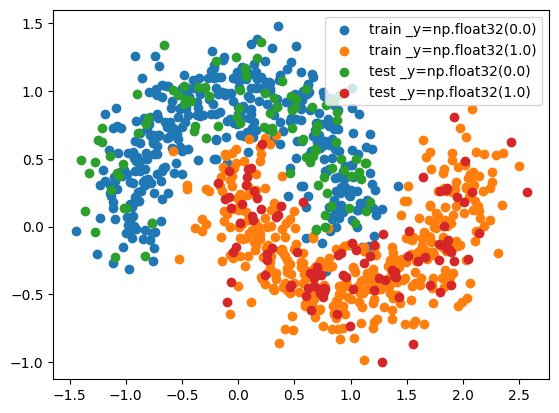

In [4]:
for _y in np.unique(y_train):
    plt.scatter(
        x=X_train[y_train == _y, 0], y=X_train[y_train == _y, 1], label=f"train {_y=}"
    )
for _y in np.unique(y_test):
    plt.scatter(
        x=X_test[y_test == _y, 0], y=X_test[y_test == _y, 1], label=f"test {_y=}"
    )
plt.legend()

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [6]:
class MoonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=4)
        self.layer_2 = nn.Linear(in_features=4, out_features=4)  # extra layer
        self.layer_3 = nn.Linear(in_features=4, out_features=1)
        self.ReLU = nn.ReLU()  # ReLU activation function
        self.Tanh = nn.Tanh()  # Tanh activation function

    def forward(self, x):  # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        z = self.layer_1(x)
        z = self.Tanh(z)
        z = self.layer_2(z)
        z = self.Tanh(z)
        z = self.layer_3(z)
        return z

In [7]:
mm = MoonModel().to(device)
print(mm)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(mm.parameters(), lr=0.08)

MoonModel(
  (layer_1): Linear(in_features=2, out_features=4, bias=True)
  (layer_2): Linear(in_features=4, out_features=4, bias=True)
  (layer_3): Linear(in_features=4, out_features=1, bias=True)
  (ReLU): ReLU()
  (Tanh): Tanh()
)


In [8]:
torch.manual_seed(42)


epochs = 4000


X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epoch in range(epochs):
    ### Training
    mm.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = mm(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    mm.eval()
    with torch.inference_mode():
        test_logits = mm(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.66862, Test loss: 0.66891
Epoch: 10 | Loss: 0.64346, Test loss: 0.64581
Epoch: 20 | Loss: 0.61668, Test loss: 0.62119
Epoch: 30 | Loss: 0.58684, Test loss: 0.59369
Epoch: 40 | Loss: 0.55409, Test loss: 0.56341
Epoch: 50 | Loss: 0.52001, Test loss: 0.53173
Epoch: 60 | Loss: 0.48686, Test loss: 0.50061
Epoch: 70 | Loss: 0.45660, Test loss: 0.47180
Epoch: 80 | Loss: 0.43030, Test loss: 0.44631
Epoch: 90 | Loss: 0.40817, Test loss: 0.42439
Epoch: 100 | Loss: 0.38982, Test loss: 0.40579
Epoch: 110 | Loss: 0.37466, Test loss: 0.39005
Epoch: 120 | Loss: 0.36210, Test loss: 0.37671
Epoch: 130 | Loss: 0.35167, Test loss: 0.36537
Epoch: 140 | Loss: 0.34299, Test loss: 0.35575
Epoch: 150 | Loss: 0.33579, Test loss: 0.34761
Epoch: 160 | Loss: 0.32984, Test loss: 0.34075
Epoch: 170 | Loss: 0.32498, Test loss: 0.33501
Epoch: 180 | Loss: 0.32102, Test loss: 0.33024
Epoch: 190 | Loss: 0.31782, Test loss: 0.32629
Epoch: 200 | Loss: 0.31524, Test loss: 0.32303
Epoch: 210 | Loss: 0.313

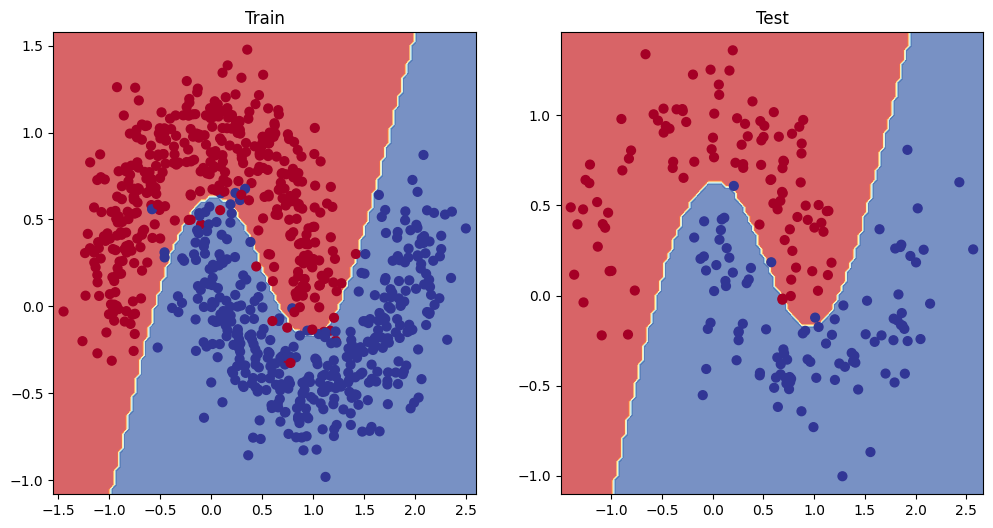

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(mm, X_train, y_train)  # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(mm, X_test, y_test)  # model_3 = has non-linearity

## Multiclass

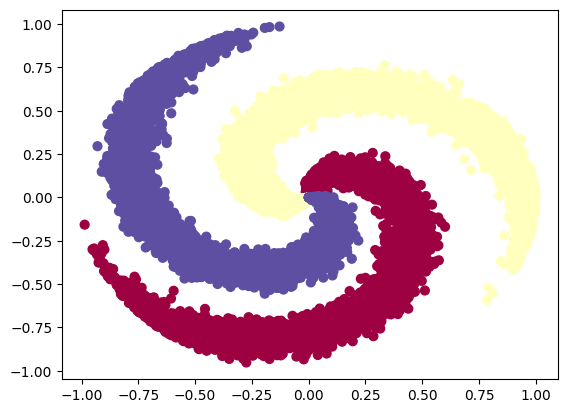

In [50]:
N = 5000  # number of points per class
D = 2  # dimensionality
K = 3  # number of classes
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype="uint8")
for j in range(K):
    ix = range(N * j, N * (j + 1))
    r = np.linspace(0.0, 1, N)  # radius
    t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2  # theta
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [51]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
class SpiralModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=12)
        self.layer_2 = nn.Linear(in_features=16, out_features=12) # extra layer
        self.layer_3 = nn.Linear(in_features=24, out_features=16) 
        self.layer_4 = nn.Linear(in_features=12, out_features=K)
        self.ReLU = nn.ReLU()  # ReLU activation function
        self.Tanh = nn.Tanh()  # Tanh activation function

    def forward(self, x):  # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        z = self.layer_1(x)
        # z = self.Tanh(z)
        # z = self.layer_2(z)
        z = self.Tanh(z)
        # z = self.layer_3(z)
        # z = self.ReLU(z)
        z = self.layer_4(z)
        return z

In [76]:
sm = SpiralModel().to(device)
print(sm)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(sm.parameters(), lr=0.03)

SpiralModel(
  (layer_1): Linear(in_features=2, out_features=12, bias=True)
  (layer_2): Linear(in_features=16, out_features=12, bias=True)
  (layer_3): Linear(in_features=24, out_features=16, bias=True)
  (layer_4): Linear(in_features=12, out_features=3, bias=True)
  (ReLU): ReLU()
  (Tanh): Tanh()
)


In [79]:
torch.manual_seed(42)

# Set number of epochs
epochs = 10000


for epoch in range(epochs):
    ### Training
    sm.train()

    # 1. Forward pass
    y_logits = sm(X_train)  # model outputs raw logits
    # y_pred = torch.softmax(y_logits, dim=1).argmax(
    #     dim=1
    # )  # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    # acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    sm.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = sm(X_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        # test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch} | Loss: {loss:.5f},  Test Loss: {test_loss:.5f}"
        )

Epoch: 0 | Loss: 0.26828,  Test Loss: 0.26461
Epoch: 10 | Loss: 0.26791,  Test Loss: 0.26422
Epoch: 20 | Loss: 0.26753,  Test Loss: 0.26384
Epoch: 30 | Loss: 0.26716,  Test Loss: 0.26346
Epoch: 40 | Loss: 0.26679,  Test Loss: 0.26308
Epoch: 50 | Loss: 0.26642,  Test Loss: 0.26270
Epoch: 60 | Loss: 0.26605,  Test Loss: 0.26232
Epoch: 70 | Loss: 0.26568,  Test Loss: 0.26194
Epoch: 80 | Loss: 0.26531,  Test Loss: 0.26157
Epoch: 90 | Loss: 0.26494,  Test Loss: 0.26119
Epoch: 100 | Loss: 0.26458,  Test Loss: 0.26082
Epoch: 110 | Loss: 0.26421,  Test Loss: 0.26045
Epoch: 120 | Loss: 0.26385,  Test Loss: 0.26008
Epoch: 130 | Loss: 0.26349,  Test Loss: 0.25971
Epoch: 140 | Loss: 0.26313,  Test Loss: 0.25934
Epoch: 150 | Loss: 0.26277,  Test Loss: 0.25897
Epoch: 160 | Loss: 0.26241,  Test Loss: 0.25861
Epoch: 170 | Loss: 0.26206,  Test Loss: 0.25824
Epoch: 180 | Loss: 0.26170,  Test Loss: 0.25788
Epoch: 190 | Loss: 0.26135,  Test Loss: 0.25752
Epoch: 200 | Loss: 0.26100,  Test Loss: 0.25716
Epo

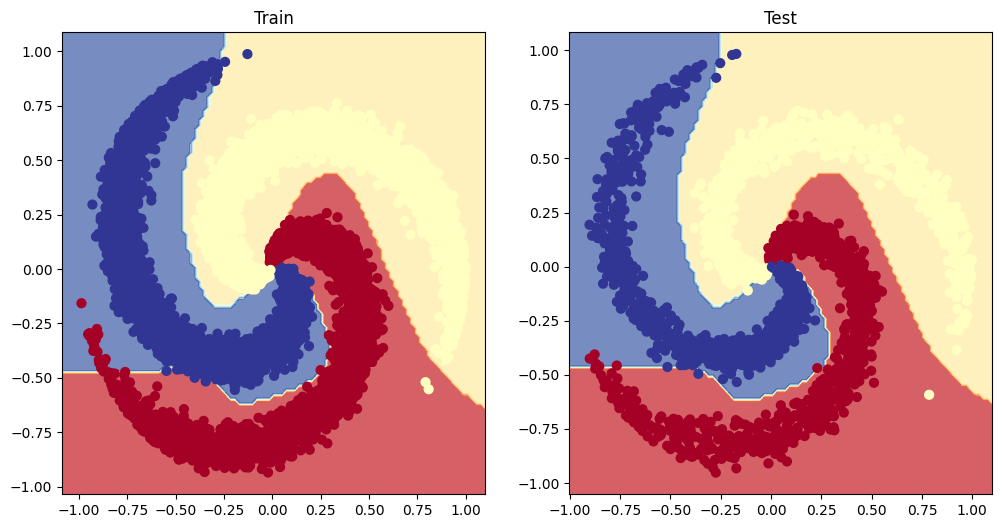

In [80]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(sm, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(sm, X_test, y_test)